# 02f - Crosswalk taxonomico PASTIS-18 -> HCAT v3 (US-074)

Espacio de etiquetas unificado para la transferencia multi-region (EPIC 12). Mapea las 18 clases PASTIS-R al estandar **HCAT v3** (Harmonized Crop and Agricultural Types, codigos de 10 digitos, prefijo `33` = `crop_type`) y las colapsa a macro-clases via el nivel de grupo de la jerarquia.

**Insumos reales del repo** (regla Arthur: cero sinteticos):
- `data/reference/eurocrops_hcat3.csv` - diccionario canonico HCAT v3 (codigos verificados).
- `data/reference/eurocrops_fr_2018_rpg_to_hcat3.csv` - crosswalk RPG frances -> HCAT3 (referencia cruzada).
- `data/reference/pastis_class_mapping.json` - nombres PASTIS + conteos reales de parcelas.

El crosswalk se materializa en `data/reference/hcat_crosswalk.parquet` y el label-space `hcat-macro` se registra en `ml/eval/class_remap.py` SIN tocar el clasificador.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import polars as pl
from IPython.display import display

REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists() and REPO != REPO.parent:
    REPO = REPO.parent
REF = REPO / 'data' / 'reference'

hcat = pl.read_csv(REF / 'eurocrops_hcat3.csv',
                   schema_overrides={'HCAT3_code': pl.Utf8})
rpg = pl.read_csv(REF / 'eurocrops_fr_2018_rpg_to_hcat3.csv',
                  schema_overrides={'HCAT3_code': pl.Utf8,
                                    'HCAT2_code': pl.Utf8})
mapping = json.loads((REF / 'pastis_class_mapping.json')
                     .read_text(encoding='utf-8'))
print(f'eurocrops_hcat3:  {hcat.shape}  (nodos HCAT v3)')
print(f'rpg_fr_to_hcat3:  {rpg.shape}  (RPG-FR -> HCAT3)')
print(f'pastis classes:   {len(mapping["classes"])} (0..19)')

eurocrops_hcat3:  (384, 2)  (nodos HCAT v3)
rpg_fr_to_hcat3:  (282, 7)  (RPG-FR -> HCAT3)
pastis classes:   20 (0..19)


## 1. Construccion del crosswalk 18 filas (tabla PASTIS->HCAT-leaf)

Se reutiliza `ml.data.hcat_crosswalk.build_crosswalk`, que resuelve cada clase PASTIS contra el CSV real por nombre agronomico y **valida** que cada `hcat_leaf_code` exista en `eurocrops_hcat3.csv` (no se inventan codigos). Tres clases sin hoja 1:1 quedan marcadas `approx`.

In [2]:
from ml.data.hcat_crosswalk import build_crosswalk

cw = build_crosswalk()
approx = cw.filter(pl.col('match_quality') == 'approx')['pastis_name'].to_list()
print('filas:', cw.height, '| approx (sin hoja 1:1):', approx)
crosswalk_tbl = cw.select(['semantic18_id', 'pastis_name', 'hcat_leaf_name',
                           'hcat_leaf_code', 'hcat_group_code',
                           'macro_hcat_group', 'macro_hcat_l1_6',
                           'n_parcels', 'match_quality'])
# Tabla crosswalk 18 filas PASTIS-18 -> HCAT codes -> macro-clases (HTML).
display(crosswalk_tbl)

2026-06-20 05:01:49 [info     ] hcat_crosswalk_built           n_approx=3 n_macro_groups=10 n_rows=18


filas: 18 | approx (sin hoja 1:1): ['Fruits, vegetables, flowers', 'Leguminous fodder', 'Mixed cereal']


semantic18_id,pastis_name,hcat_leaf_name,hcat_leaf_code,hcat_group_code,macro_hcat_group,macro_hcat_l1_6,n_parcels,match_quality
i64,str,str,str,str,str,str,i64,str
0,"""Meadow""","""pasture_meadow_grassland_grass""","""3302000000""","""3302000000""","""grassland""","""OTHER""",31292,"""exact"""
1,"""Soft winter wheat""","""winter_common_soft_wheat""","""3301010101""","""3301010000""","""cereals""","""CEREALS""",8206,"""exact"""
2,"""Corn""","""grain_maize_corn_popcorn""","""3301010600""","""3301010000""","""cereals""","""CEREALS""",13123,"""exact"""
3,"""Winter barley""","""winter_barley""","""3301010401""","""3301010000""","""cereals""","""CEREALS""",2766,"""exact"""
4,"""Winter rapeseed""","""winter_rapeseed_rape""","""3301060401""","""3301060000""","""oilseed_industrial""","""OILSEEDS""",1769,"""exact"""
…,…,…,…,…,…,…,…,…
13,"""Leguminous fodder""","""legumes_harvested_green""","""3301090300""","""3301090000""","""legumes_fodder""","""LEGUMES""",3174,"""approx"""
14,"""Soybeans""","""soy_soybeans""","""3301160000""","""3301160000""","""soybean""","""LEGUMES""",1212,"""exact"""
15,"""Orchard""","""orchards_fruits""","""3303010000""","""3303010000""","""orchard""","""PERMANENT_WOODY""",2998,"""exact"""


## 2. Long-tail PASTIS: Meadow domina (~45% de la masa)

El conteo real de parcelas (del JSON) muestra el desbalance que hunde el F1-macro a 18 clases: Meadow (31292) y Corn (13123) concentran la masa. Barplot horizontal ordenado por `n_parcels`.

total parcelas (18 clases): 85951 | Meadow: 31292 (36.4%)


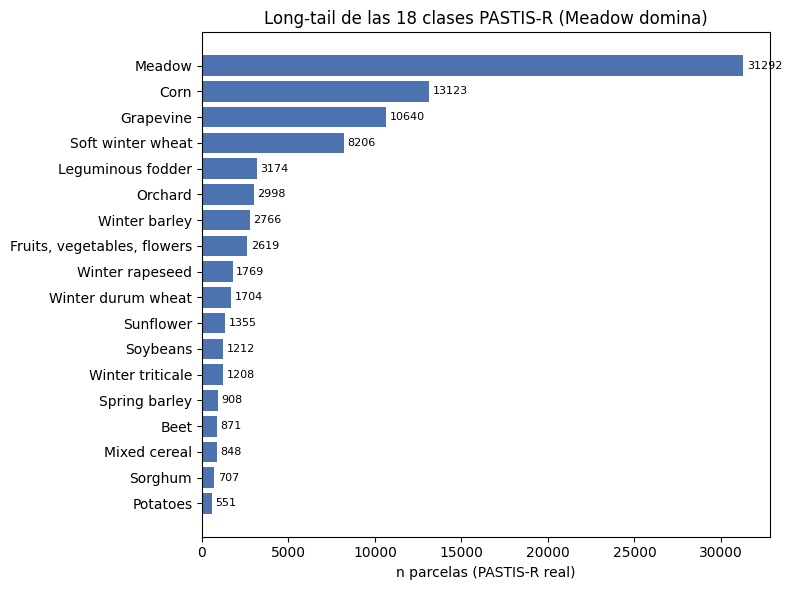

In [3]:
total = cw['n_parcels'].sum()
meadow = cw.filter(pl.col('pastis_name') == 'Meadow')['n_parcels'][0]
print(f'total parcelas (18 clases): {total} | Meadow: {meadow} '
      f'({100 * meadow / total:.1f}%)')
ordered = cw.sort('n_parcels')
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(ordered['pastis_name'].to_list(),
        ordered['n_parcels'].to_list(), color='#4c72b0')
ax.set_xlabel('n parcelas (PASTIS-R real)')
ax.set_title('Long-tail de las 18 clases PASTIS-R (Meadow domina)')
for i, v in enumerate(ordered['n_parcels'].to_list()):
    ax.text(v + 200, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()
plt.close(fig)

## 3. Colapso a 11 macro-clases HCAT (tabla con n_parcels acumulado)

El nodo de grupo L2 (6 digitos significativos; L1 para pasture/permanent) produce 10 macro-grupos de cultivo. Con la macro-clase `void` (partial-label, background/fuera de nomenclatura) el vocabulario completo es **11**. Meadow queda **aislado** en `grassland`, mitigando el long-tail.

In [4]:
from ml.data.hcat_crosswalk import MACRO_HCAT_GROUPS

# Tabla colapso macro-grupos con n_parcels acumulado (group_by Polars).
macro = (cw.group_by('macro_hcat_group', 'hcat_group_code')
           .agg(pl.col('n_parcels').sum().alias('n_parcels'),
                pl.len().alias('n_clases_pastis'),
                pl.col('pastis_name').sort().str.join(', ').alias('clases_pastis'))
           .sort('n_parcels', descending=True))
print('macro-grupos de cultivo:', cw['macro_hcat_group'].n_unique(),
      '| + void =', len(MACRO_HCAT_GROUPS), 'macro-clases canonicas')
print('familias legadas (l1_6):', cw['macro_hcat_l1_6'].n_unique())
display(macro)

macro-grupos de cultivo: 10 | + void = 11 macro-clases canonicas
familias legadas (l1_6): 6


macro_hcat_group,hcat_group_code,n_parcels,n_clases_pastis,clases_pastis
str,str,i64,u32,str
"""grassland""","""3302000000""",31292,1,"""Meadow"""
"""cereals""","""3301010000""",29470,8,"""Corn, Mixed cereal, Soft winte…"
"""vineyard""","""3303060000""",10640,1,"""Grapevine"""
"""legumes_fodder""","""3301090000""",3174,1,"""Leguminous fodder"""
"""oilseed_industrial""","""3301060000""",3124,2,"""Sunflower, Winter rapeseed"""
"""orchard""","""3303010000""",2998,1,"""Orchard"""
"""vegetables""","""3301070000""",2619,1,"""Fruits, vegetables, flowers"""
"""soybean""","""3301160000""",1212,1,"""Soybeans"""
"""sugar_beet""","""3301290000""",871,1,"""Beet"""


## 4. Comparativa de compresion: 18 vs 11 macro vs 6 familias

El grupo HCAT comprime el long-tail. Las 6 familias legadas (`hcat_l1_6`, XGB 0.6535 F1-macro) son aun mas gruesas; las 11 macro-clases HCAT son el punto canonico de E12 (mas finas para multi-region).

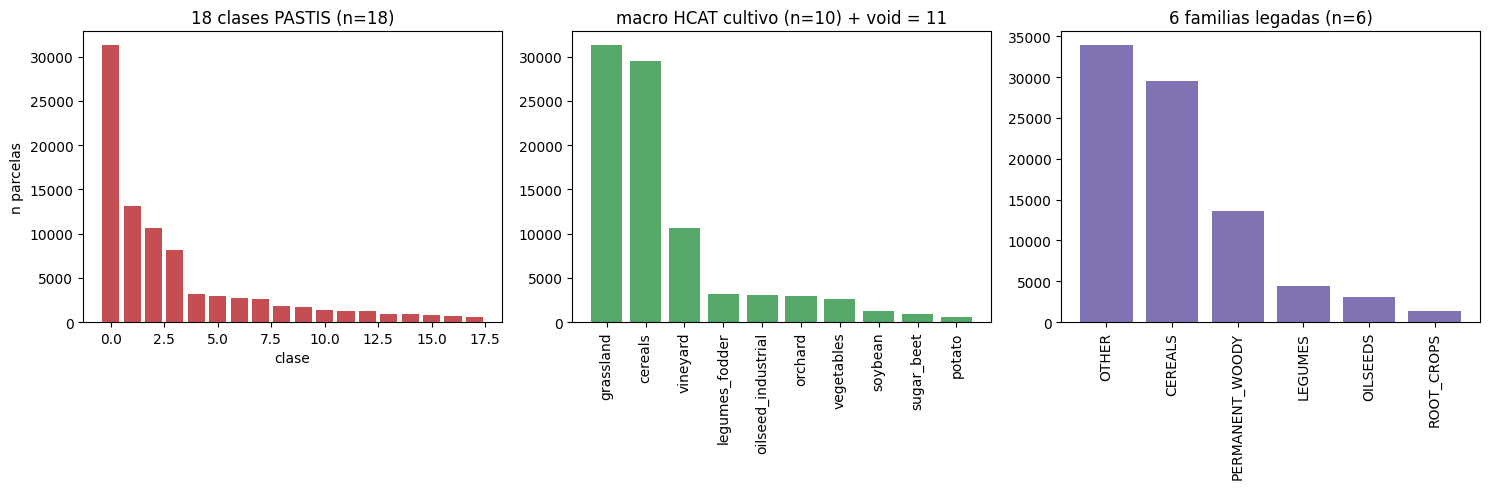

In [5]:
l16 = (cw.group_by('macro_hcat_l1_6')
         .agg(pl.col('n_parcels').sum().alias('n'))
         .sort('n', descending=True))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(range(cw.height), cw.sort('n_parcels', descending=True)
            ['n_parcels'].to_list(), color='#c44e52')
axes[0].set_title(f'18 clases PASTIS (n={cw.height})')
axes[0].set_xlabel('clase')
axes[0].set_ylabel('n parcelas')
axes[1].bar(macro['macro_hcat_group'].to_list(),
            macro['n_parcels'].to_list(), color='#55a868')
axes[1].set_title(f'macro HCAT cultivo (n={macro.height}) + void = 11')
axes[1].tick_params(axis='x', rotation=90)
axes[2].bar(l16['macro_hcat_l1_6'].to_list(),
            l16['n'].to_list(), color='#8172b3')
axes[2].set_title(f'6 familias legadas (n={l16.height})')
axes[2].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()
plt.close(fig)

## 5. Jerarquia HCAT (4 niveles) tocada por PASTIS-18 -- treemap

Treemap por rama HCAT L1 (`arable 3301` / `pasture 3302` / `permanent 3303`), area proporcional a `n_parcels`, agrupado por macro-grupo (L2). Solo se dibujan los nodos que PASTIS realmente alcanza. Implementado con rectangulos de matplotlib (sin dependencias extra).

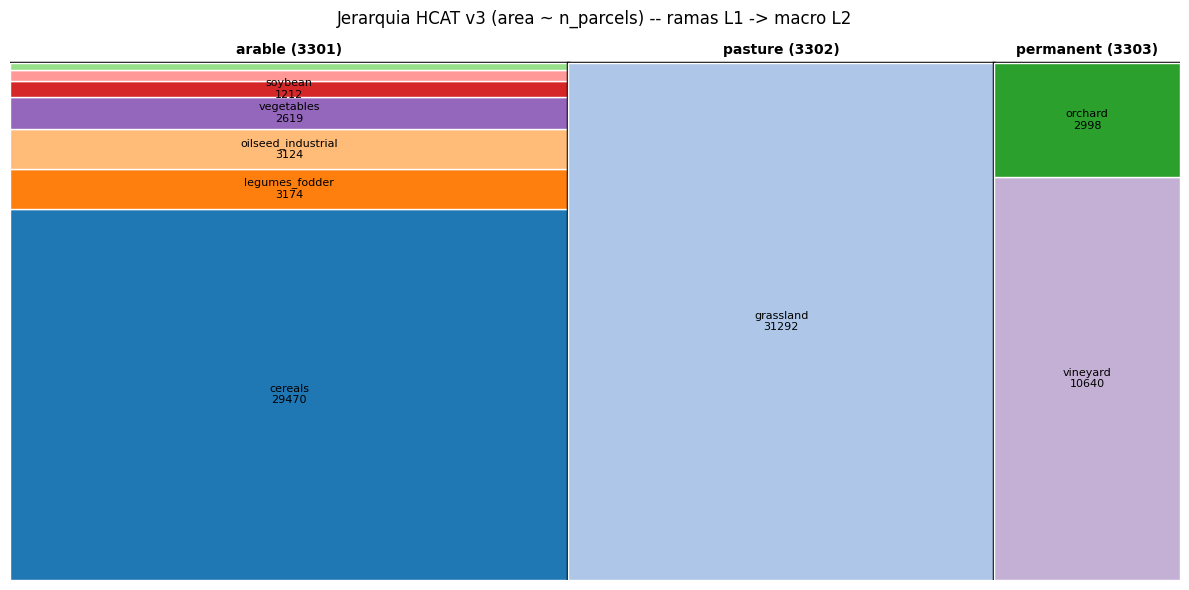

In [6]:
def _slice_layout(items, x, y, w, h):
    # Slice-and-dice simple: corta el lado mayor proporcional al peso.
    total = sum(v for _, v in items)
    out, off = [], 0.0
    for label, val in items:
        frac = val / total if total else 0.0
        if w >= h:
            out.append((label, val, x + off * w, y, frac * w, h))
        else:
            out.append((label, val, x, y + off * h, w, frac * h))
        off += frac
    return out

branch = cw.with_columns(
    pl.col('hcat_leaf_code').str.slice(0, 4).alias('hcat_l1_code'))
L1_NAME = {'3301': 'arable (3301)', '3302': 'pasture (3302)',
           '3303': 'permanent (3303)'}
l1_tot = (branch.group_by('hcat_l1_code')
                .agg(pl.col('n_parcels').sum().alias('n'))
                .sort('hcat_l1_code'))
l1_items = [(c, n) for c, n in zip(l1_tot['hcat_l1_code'].to_list(),
                                   l1_tot['n'].to_list())]
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap('tab20')
macro_order = sorted(cw['macro_hcat_group'].unique().to_list())
color = {m: cmap(i % 20) for i, m in enumerate(macro_order)}
for (l1, _, lx, ly, lw, lh) in _slice_layout(l1_items, 0, 0, 1, 1):
    ax.add_patch(mpatches.Rectangle((lx, ly), lw, lh, fill=False,
                                    edgecolor='black', lw=2.5))
    ax.text(lx + lw / 2, ly + lh + 0.012, L1_NAME[l1], ha='center',
            va='bottom', fontsize=10, fontweight='bold')
    sub = (branch.filter(pl.col('hcat_l1_code') == l1)
                 .group_by('macro_hcat_group')
                 .agg(pl.col('n_parcels').sum().alias('n'))
                 .sort('n', descending=True))
    sub_items = [(m, n) for m, n in zip(sub['macro_hcat_group'].to_list(),
                                        sub['n'].to_list())]
    for (m, val, mx, my, mw, mh) in _slice_layout(sub_items, lx, ly, lw, lh):
        ax.add_patch(mpatches.Rectangle((mx, my), mw, mh, facecolor=color[m],
                                        edgecolor='white', lw=1.0))
        if mw * mh > 0.012:
            ax.text(mx + mw / 2, my + mh / 2, f'{m}\n{val}', ha='center',
                    va='center', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.06)
ax.axis('off')
ax.set_title('Jerarquia HCAT v3 (area ~ n_parcels) -- ramas L1 -> macro L2')
plt.tight_layout()
plt.show()
plt.close(fig)

## 6. Materializacion del parquet + roundtrip

Se escribe `data/reference/hcat_crosswalk.parquet` (Polars, codigos como `Utf8` para preservar ceros) y se valida la lectura.

In [7]:
from ml.data.hcat_crosswalk import (CROSSWALK_PARQUET, load_crosswalk,
                                    write_crosswalk)

p = write_crosswalk()
rt = load_crosswalk()
assert rt.height == 18
assert rt.schema['hcat_leaf_code'] == pl.Utf8
assert rt.equals(cw)
size_kb = CROSSWALK_PARQUET.stat().st_size / 1024
print(f'parquet: {p}  ({size_kb:.1f} KB, {rt.height} filas)')
display(rt.head(3))

2026-06-20 05:01:49 [info     ] hcat_crosswalk_built           n_approx=3 n_macro_groups=10 n_rows=18


2026-06-20 05:01:49 [info     ] hcat_crosswalk_written         n_rows=18 path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\reference\hcat_crosswalk.parquet


parquet: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\reference\hcat_crosswalk.parquet  (5.2 KB, 18 filas)


pastis_id,semantic18_id,pastis_name,hcat_leaf_name,hcat_leaf_code,hcat_group_code,macro_hcat_group,macro_hcat_l1_6,n_parcels,match_quality,void_convention
i64,i64,str,str,str,str,str,str,i64,str,str
1,0,"""Meadow""","""pasture_meadow_grassland_grass""","""3302000000""","""3302000000""","""grassland""","""OTHER""",31292,"""exact""","""crop"""
2,1,"""Soft winter wheat""","""winter_common_soft_wheat""","""3301010101""","""3301010000""","""cereals""","""CEREALS""",8206,"""exact""","""crop"""
3,2,"""Corn""","""grain_maize_corn_popcorn""","""3301010600""","""3301010000""","""cereals""","""CEREALS""",13123,"""exact""","""crop"""


## 7. Demo viva del seam: label-space `hcat-macro` registrado (US-053)

El registry US-053 queda AMPLIADO sin tocar `classify.py`. `hcat-macro` mantiene los 18 ids y EXPONE el mapeo macro en `class_names`. Se muestra `get_label_space('hcat-macro').class_names` y se verifica que `france-9` sigue intacto.

In [8]:
from ml.eval.class_remap import get_label_space, list_label_spaces

print('label-spaces:', list_label_spaces())
hm = get_label_space('hcat-macro')
print('kept ids:', len(hm.kept_class_ids), '| dropped:', hm.dropped_class_ids)
print('france-9 intacto:', len(get_label_space('france-9').kept_class_ids),
      'kept')
seam = pl.DataFrame({'sem18_id': list(hm.class_names),
                     'macro_label': list(hm.class_names.values())})
# Demo viva: get_label_space('hcat-macro').class_names
display(seam)

label-spaces: ('france-9', 'hcat-macro')
kept ids: 18 | dropped: ()
france-9 intacto: 9 kept


sem18_id,macro_label
i64,str
0,"""GRASSLAND_OTHER|grassland|Mead…"
1,"""CEREALS|cereals|Soft winter wh…"
2,"""CEREALS|cereals|Corn"""
3,"""CEREALS|cereals|Winter barley"""
4,"""OILSEEDS|oilseed_industrial|Wi…"
…,…
13,"""LEGUMES|legumes_fodder|Legumin…"
14,"""LEGUMES|soybean|Soybeans"""
15,"""PERMANENT_WOODY|orchard|Orchar…"


## 8. Convencion void/background + partial-label (UniSeg)

| Dataset | Background | Void / out-of-scope | Unificado |
|---------|-----------|---------------------|-----------|
| PASTIS-R | id `0` ('stuff') | id `19` (fuera de nomenclatura / <50% overlap) | `ignore_index=255` |
| Sen4AgriNet | clase `0` del `linear_encoder` | sin codigo FAO-ICC -> HCAT | `0`->ignore; sin-mapeo->null-class |
| EuroCropsML | sin pixel background (tabular) | clase HCAT ausente en el split | ausencia->null-class (no falso negativo) |

**Regla unica**: `background/void -> ignore`; `ausencia cross-dataset -> null-class` (partial-label, no negativo duro). `ignore_index=255` reutiliza `HARNESS_IGNORE_INDEX` de US-030. La 11a macro-clase `void` absorbe el background/fuera-de-nomenclatura como partial-label.

**Recomendacion de loss (US-075/US-076, no implementada aqui)**: BCE class-independent (un sigmoide por clase HCAT, no softmax exclusivo) + cross-dataset relation loss que solo penaliza clases presentes en cada dataset, evitando el conflicto de gradiente entre regiones. US-074 entrega el espacio comun y la convencion; el loss lo consume la US siguiente.

In [9]:
from ml.eval.class_remap import HARNESS_IGNORE_INDEX

void = mapping['classes']['19']
bg = mapping['classes']['0']
ix = HARNESS_IGNORE_INDEX
print(f"PASTIS id 0 (background): {bg['name']} -> ignore_index={ix}")
print(f"PASTIS id 19 (void): {void['name']} "
      f"(n_parcels={void['n_parcels']}) -> ignore_index={ix}")
print('void_convention en crosswalk:',
      cw['void_convention'].unique().to_list())
print('macro-clase partial-label que absorbe background/void: void')

PASTIS id 0 (background): Background -> ignore_index=255
PASTIS id 19 (void): Void label (n_parcels=35924) -> ignore_index=255
void_convention en crosswalk: ['crop']
macro-clase partial-label que absorbe background/void: void
